# Whakaari Cause–Trigger Analysis

This notebook runs the Cause–Trigger algorithm on the Whakaari dataset using three causal-discovery backends:

1. **HMML** — baseline.
2. **PCMCI** — lagged causal-discovery sensitivity backend.
3. **PCMCI+** — lagged + contemporaneous causal-discovery backend.

## 1. Imports and paths

In [1]:
from pathlib import Path
import sys
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "whakaari"

for path in [SRC_DIR, NOTEBOOK_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from cause_trigger_whakaari import *

EVENT_TIME = pd.Timestamp("2019-12-09 01:11:00", tz="UTC")
WHAKAARI_PATH = DATA_DIR / "whakaari_final.csv"

In [2]:
X_full = load_model_frame(WHAKAARI_PATH)

CASE_START = EVENT_TIME - pd.Timedelta(days=14)
CASE_END = EVENT_TIME + pd.Timedelta(days=3)

X = X_full.loc[CASE_START:CASE_END].copy()

display(pd.DataFrame([model_overview(X, EFFECT)]))

,n_rows,n_variables,start,end,inferred_frequency,effect,effect_min,effect_median,effect_mean,effect_max,effect_abs_mean,effect_iqr,effect_n_unique
0,391,8,2019-11-25 02:00:00+00:00,2019-12-12 01:00:00+00:00,None,effect_tremor_5_15_scaled,-3.461211,0.683565,0.515423,4.561627,1.079183,0.552667,391


## 2. Automatic parameter selection, Main configuration and split check

In [ ]:
from parameter_extraction import find_parameters

selected_distribution, selected_lag = find_parameters(
    X=X,
    target_series=X[EFFECT],
    max_lags=12,
    criterion="aic",
    fallback_lag=1,
    fallback_distribution="gaussian",
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,effect,selected_lag,selected_distribution,lag_method,max_lags
0,effect_tremor_5_15_scaled,3,gaussian,VAR-AIC,6


In [4]:
workflow = WhakaariWorkflowConfig(
    effect=EFFECT,
    event_time=EVENT_TIME,
    alpha=0.05,
    selected_lag=int(selected_lag),
    max_lags=12,
    min_I1_length=48,
    min_I2_length=48,
    distribution=selected_distribution,
    parameter_source="automatic",
)

,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,event_time,distance_to_event,boundary_split,split_end_index,split_end_time,split_score,split_lag_buffer,split_score_I2_length,signed_mean_I1,signed_mean_I2
0,effect_tremor_5_15_scaled,343,2019-12-09 23:00:00+00:00,343,48,0.456334,0.937663,0.481328,2019-12-09 01:11:00+00:00,0 days 21:49:00,True,391,2019-12-12 01:00:00+00:00,0.481328,None,None,0.456334,0.937663


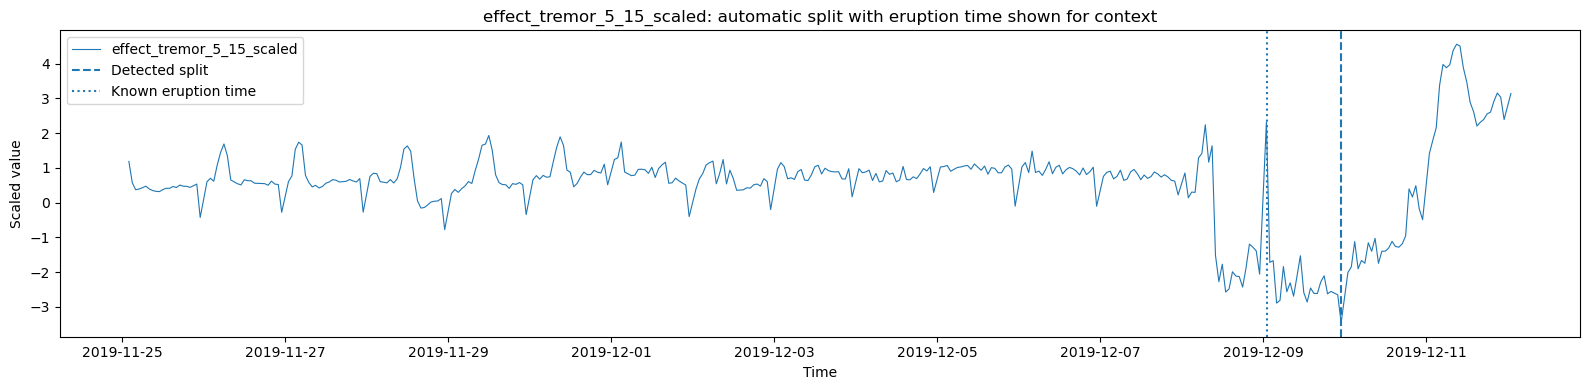

In [6]:
main_split = split_diagnostics(
    X,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
)

display(pd.DataFrame([main_split]))

plot_effect_with_split(
    X,
    EFFECT,
    main_split,
    event_time=workflow.event_time,
)

## 3. Main run

HMML is the baseline. PCMCI/PCMCI+ are extensions.

In [7]:
results, comparison, diagnostics = run_suite(
    X,
    workflow,
    lag=workflow.selected_lag,
    distribution=workflow.distribution,
    cond_ind_test="parcorr",
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: Const

In [8]:
#display(compact_comparison(comparison))
display(comparison)

,run,effect,backend,parameter_source,configured_lags,configured_distribution,v_weighting,refit_method,refit_nonzero_beta_count,refit_alpha_used,...,target_abs_mean_difference,B1,B2,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_contemporaneous_links,stop_reason
0,hmml_backend_beta,effect_tremor_5_15_scaled,hmml,automatic_hmml_lag3_gaussian_backend_beta,3,gaussian,backend,None,None,None,...,0.481328,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled]","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...",False,[hydro_2_5_scaled],[hydro_2_5_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, hydro_2_5_scaled)]",0,None
1,pcmci_ridge,effect_tremor_5_15_scaled,pcmci,automatic_pcmci_lag3_gaussian_ridge_refit,3,gaussian,refit,ridge,None,None,...,0.481328,[ratio_4p5_8_over_8_16_scaled],[],False,[],[],[],[],0,No lagged non-target B2 variables available to...
2,pcmci_plus_ridge,effect_tremor_5_15_scaled,pcmci_plus,automatic_pcmci_plus_lag3_gaussian_ridge_refit,3,gaussian,refit,ridge,None,None,...,0.481328,[hydro_2_5_scaled],[],True,[],[],[],[],1,No lagged non-target B2 variables available to...


In [9]:
#display(compact_diagnostics(diagnostics))
display(diagnostics)

,accepted,f_stat,critical_f,p_value,rss_reduced,rss_full,rss_reduction,rss_reduction_ratio,gamma_1,gamma_2,...,cause,trigger_source,trigger_is_contemporaneous_pcmci_plus,trigger_tau0_info,run,effect,backend,parameter_source,v_weighting,refit_method
0,True,62.500016,4.072654,7.581105e-10,111.348793,44.752618,66.596175,0.598086,2.918538,-0.571605,...,SO2_flux_scaled,lagged_B2,False,None,hmml_backend_beta,effect_tremor_5_15_scaled,hmml,automatic_hmml_lag3_gaussian_backend_beta,backend,None


### PCMCI+ run

In [11]:
result_tau0, diag_tau0, row_tau0 = run_one(
    X,
    workflow,
    run_name="pcmci_plus_tau0_ridge",
    backend="pcmci_plus",
    parameter_source="automatic_pcmci_plus_tau0_ridge",
    use_contemporaneous_triggers=True,
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)


## 4. Sensitivity check

In [12]:
sensitivity = run_sensitivity_grid(
    X,
    workflow,
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
    cond_ind_test="parcorr",
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) *

In [13]:
#display(compact_sensitivity(sensitivity))
display(sensitivity)

,effect,backend,lag,distribution,cond_ind_test,run,v_weighting,refit_method,refit_nonzero_beta_count,refit_alpha_used,...,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_contemporaneous_links,n_diagnostics,min_p_value,max_rss_reduction_ratio,error
0,effect_tremor_5_15_scaled,hmml,1,gaussian,None,hmml_backend_beta,backend,None,NaN,NaN,...,True,[],[],[],[],0.0,0.0,NaN,NaN,None
1,effect_tremor_5_15_scaled,hmml,2,gaussian,None,hmml_backend_beta,backend,None,NaN,NaN,...,False,[hydro_2_5_scaled],[hydro_2_5_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, hydro_2_5_scaled)]",0.0,1.0,3.405846e-09,0.560153,None
2,effect_tremor_5_15_scaled,hmml,3,gaussian,None,hmml_backend_beta,backend,None,NaN,NaN,...,False,[hydro_2_5_scaled],[hydro_2_5_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, hydro_2_5_scaled)]",0.0,1.0,7.581105e-10,0.598086,None
3,effect_tremor_5_15_scaled,hmml,4,gaussian,None,hmml_backend_beta,backend,None,NaN,NaN,...,False,"[hydro_2_5_scaled, GNSS_deformation_scaled]",[hydro_2_5_scaled],[GNSS_deformation_scaled],"[(GNSS_deformation_scaled, hydro_2_5_scaled)]",0.0,2.0,2.756966e-10,0.625677,None
4,effect_tremor_5_15_scaled,hmml,5,gaussian,None,hmml_backend_beta,backend,None,NaN,NaN,...,True,[],[],[],[],0.0,0.0,NaN,NaN,None
5,effect_tremor_5_15_scaled,hmml,6,gaussian,None,hmml_backend_beta,backend,None,NaN,NaN,...,True,[],[],[],[],0.0,0.0,NaN,NaN,None
6,effect_tremor_5_15_scaled,hmml,7,gaussian,None,hmml_backend_beta,backend,None,NaN,NaN,...,True,"[hydro_2_5_scaled, event_rate_2_5_scaled]",[hydro_2_5_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, hydro_2_5_scaled)]",0.0,2.0,2.319589e-12,0.730133,None
7,effect_tremor_5_15_scaled,hmml,8,gaussian,None,hmml_backend_beta,backend,None,NaN,NaN,...,True,"[event_rate_2_5_scaled, GNSS_deformation_scaled]",[GNSS_deformation_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, GNSS_deformation_scaled)]",0.0,2.0,1.799284e-04,0.318989,None
8,effect_tremor_5_15_scaled,hmml,9,gaussian,None,hmml_backend_beta,backend,None,NaN,NaN,...,False,"[hydro_2_5_scaled, event_rate_2_5_scaled, pres...","[hydro_2_5_scaled, event_rate_2_5_scaled]","[SO2_flux_scaled, hydro_2_5_scaled]","[(SO2_flux_scaled, hydro_2_5_scaled), (hydro_2...",0.0,3.0,2.377489e-08,0.583860,None
9,effect_tremor_5_15_scaled,hmml,10,gaussian,None,hmml_backend_beta,backend,None,NaN,NaN,...,False,[event_rate_2_5_scaled],[],[],[],0.0,1.0,9.426542e-01,0.000150,None


In [14]:
display(accepted_sensitivity_rows(sensitivity))

,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,accepted_triggers,causes,pairs,error
1,hmml_backend_beta,hmml,2,gaussian,2019-12-09 23:00:00+00:00,343.0,48.0,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...",[hydro_2_5_scaled],[hydro_2_5_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, hydro_2_5_scaled)]",None
2,hmml_backend_beta,hmml,3,gaussian,2019-12-09 23:00:00+00:00,343.0,48.0,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...",[hydro_2_5_scaled],[hydro_2_5_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, hydro_2_5_scaled)]",None
3,hmml_backend_beta,hmml,4,gaussian,2019-12-09 23:00:00+00:00,343.0,48.0,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, GNSS_deformation_scaled]",[hydro_2_5_scaled],[GNSS_deformation_scaled],"[(GNSS_deformation_scaled, hydro_2_5_scaled)]",None
6,hmml_backend_beta,hmml,7,gaussian,2019-12-09 23:00:00+00:00,343.0,48.0,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, event_rate_2_5_scaled]",[hydro_2_5_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, hydro_2_5_scaled)]",None
7,hmml_backend_beta,hmml,8,gaussian,2019-12-09 23:00:00+00:00,343.0,48.0,"[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...","[event_rate_2_5_scaled, GNSS_deformation_scaled]",[GNSS_deformation_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, GNSS_deformation_scaled)]",None
8,hmml_backend_beta,hmml,9,gaussian,2019-12-09 23:00:00+00:00,343.0,48.0,"[hydro_2_5_scaled, event_rate_2_5_scaled, API_...","[hydro_2_5_scaled, event_rate_2_5_scaled, pres...","[hydro_2_5_scaled, event_rate_2_5_scaled]","[SO2_flux_scaled, hydro_2_5_scaled]","[(SO2_flux_scaled, hydro_2_5_scaled), (hydro_2...",None
